## Import packages

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import integrate
import sys
import os
sys.path.append("../../../../")
from ADFWI.propagator  import *
from ADFWI.model       import *
from ADFWI.view        import *
from ADFWI.utils       import *
from ADFWI.survey      import *
from ADFWI.fwi         import *


project_path = "./examples/elastic/Iso-elastic-Anomaly/data"
if not os.path.exists(os.path.join(project_path,"model")):
    os.makedirs(os.path.join(project_path,"model"))
if not os.path.exists(os.path.join(project_path,"waveform")):
    os.makedirs(os.path.join(project_path,"waveform"))
if not os.path.exists(os.path.join(project_path,"survey")):
    os.makedirs(os.path.join(project_path,"survey"))
if not os.path.exists(os.path.join(project_path,"inversion")):
    os.makedirs(os.path.join(project_path,"inversion"))

## Define the basic model parameter

In [ ]:
device = "cuda:3"         # Specify the GPU device
dtype = torch.float32     # Set data type to 32-bit floating point
ox, oz = 0, 0             # Origin coordinates for x and z directions
nz, nx = 80, 180          # Grid dimensions in z and x directions
dx, dz = 10, 10           # Grid spacing in x and z directions
nt, dt = 1000,0.001       # Time steps and time interval
nabc   = 50               # Thickness of the absorbing boundary layer
f0     = 25               # Initial frequency in Hz
free_surface = True       # Enable free surface boundary condition

## Define the initial velocity model

In [3]:
# Anomaly Model
vp_true      = np.ones((nz,nx))*3000
vs_true      = np.ones((nz,nx))*2000
rho_true     = np.ones((nz,nx))*2450

# anomaly 0 
center_x = nx//3
center_z = nz//2
center_r = 10
mask = vp_true == -1
for i in range(nz):
    for j in range(nx):
        if np.sqrt((i-center_z)**2 + (j-center_x)**2)<center_r:
            mask[i,j] = True
vp_true[mask] *= 1.1  # Increase vp by 5%


# anomaly 1
center_x = nx//3*2
center_z = nz//2
center_r = 10
mask = vp_true == -1
for i in range(nz):
    for j in range(nx):
        if np.sqrt((i-center_z)**2 + (j-center_x)**2)<center_r:
            mask[i,j] = True
vs_true[mask] *= 1.1  # Increase vs by 5%

# init model
vp_init      = np.ones((nz,nx))*3000
vs_init      = np.ones((nz,nx))*2000
rho_init     = np.ones((nz,nx))*2450

# processing the water layer
model = IsotropicElasticModel(
                ox,oz,nx,nz,dx,dz,
                vp_init,vs_init,rho_init,
                vp_bound =[vp_true.min(),vp_true.max()],
                vs_bound =[vs_true.min(),vs_true.max()],
                vp_grad = True, vs_grad = True, rho_grad=False,
                auto_update_rho=False,auto_update_vp=False,
                free_surface=free_surface,
                abc_type="PML",abc_jerjan_alpha=0.007,nabc=nabc,
                device=device,dtype=dtype)

model.save(os.path.join(project_path,"model/init_model.npz"))
print(model.__repr__())

model with parameters ['vp', 'vs', 'rho']:
  Model vp  :  3000.00 -  3000.00 m/s   , requires_grad = True, constrain bound: 3000.0 - 3300.0000000000005
  Model vs  :  2000.00 -  2000.00 m/s   , requires_grad = True, constrain bound: 2000.0 - 2200.0
  Model rho :  2450.00 -  2450.00 kg/m^3, requires_grad = False, constrain bound: None - None
  Model orig: ox =   0.00, oz =   0.00 m
  Model grid: dx =  10.00, dz =  10.00 m
  Model dims: nx =    180, nz =     80
  Model size: 43200
  Free surface: True
  Absorbing layers: 50



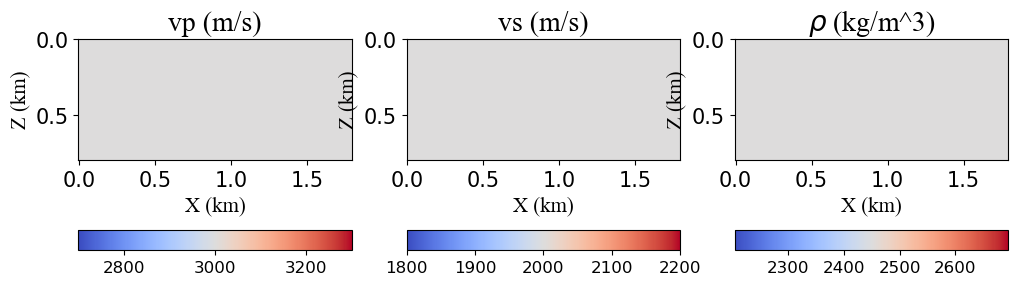

In [4]:
model._plot_vp_vs_rho(figsize=(12,5),wspace=0.2,cbar_pad_fraction=0.18,cbar_height=0.04,cmap='coolwarm',save_path=os.path.join(project_path,"model/init_vp_vs_rho.png"),show=True)

## Define the observed systems: Survey = Source + Receiver

In [5]:
# Define source positions in the model
src_z = np.array([5 for i in range(1,nx-1,5)]) 
src_x = np.array([i  for i in range(1,nx-1,5)])

# Generate wavelet for the source
src_t, src_v = wavelet(nt, dt, f0, amp0=1)  # Create time and wavelet amplitude
src_v = integrate.cumtrapz(src_v, axis=-1, initial=0)  # Integrate wavelet to get velocity

source = Source(nt=nt, dt=dt, f0=f0)  # Initialize source object

# Method 1: Add multiple sources at once (commented out)
# source.add_sources(src_x=src_x, src_z=src_z, src_wavelet=src_v, src_type='mt', src_mt=np.array([[1,0,0],[0,1,0],[0,0,1]]))

# Method 2: Loop through each source position to add them individually
for i in range(len(src_x)):
    source.add_source(src_x=src_x[i],src_z=src_z[i],src_wavelet=src_v,src_type="mt",src_mt=np.array([[0,0,1],[0,0,0],[0,0,0]]))
    # source.add_source(src_x=src_x[i],src_z=src_z[i],src_wavelet=src_v,src_type="mt",src_mt=np.array([[1,0,0],[0,1,0],[0,0,1]]))

In [6]:
# Define receiver positions in the model
rcv_z = np.array([5 for i in range(0,nx,1)])
rcv_x = np.array([j  for j in range(0,nx,1)])

receiver = Receiver(nt=nt, dt=dt)  # Initialize receiver object

# Method 1: Add all receivers at once (commented out)
# receiver.add_receivers(rcv_x=rcv_x, rcv_z=rcv_z, rcv_type='pr')

# Method 2: Loop through each receiver position to add them individually
for i in range(len(rcv_x)):
    receiver.add_receiver(rcv_x=rcv_x[i], rcv_z=rcv_z[i], rcv_type="pr")

Survey Information:
Seismic Source:
  Source wavelet: 1000 samples at 1.00 ms
  Source number : 36
  Source types  : ['mt']
  Source x range: 1 - 176 (grids)
  Source z range: 5 - 5 (grids)

Seismic Receiver:
  Receiver data   : 1000 samples at 1.00 ms
  Receiver number : 180
  Receiver types  : ['pr']
  Receiver x range: 0 - 179 (grids)
  Receiver z range: 5 - 5 (grids)



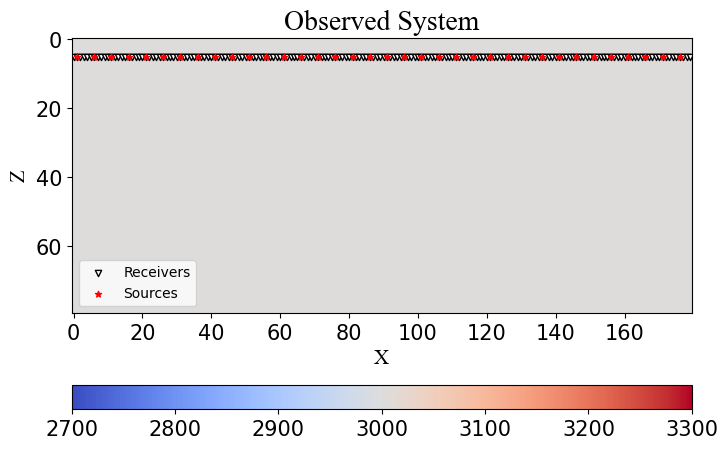

In [7]:
# survey
survey = Survey(source=source,receiver=receiver)
print(survey.__repr__())
survey.plot(model.vp,cmap='coolwarm',save_path=os.path.join(project_path,"survey/observed_system_init.png"),show=True)


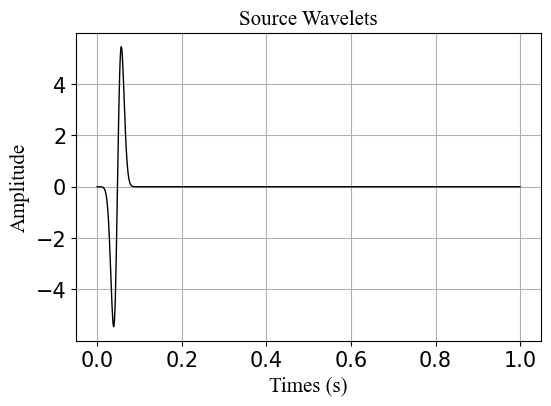

In [8]:
# Plot the wavelet used in the source
source.plot_wavelet(save_path=os.path.join(project_path,"survey/wavelets_init.png"),show=True)

## Define the propagator

In [9]:
# Initialize the wave propagator using the specified model and survey configuration
F = ElasticPropagator(model,survey,device=device)

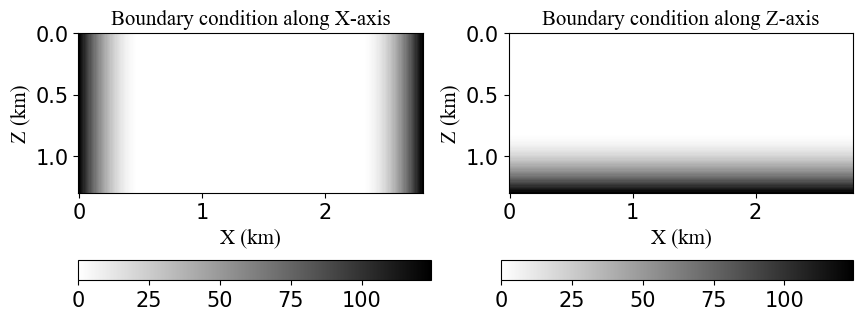

In [10]:
# Retrieve the damping array from the propagator and plot it to visualize boundary conditions
if model.abc_type == "PML":
    bcx = F.bcx
    bcz = F.bcz
    title_param = {'family':'Times New Roman','weight':'normal','size': 15}
    plot_bcx_bcz(bcx,bcz,dx=dx,dz=dz,wspace=0.25,title_param=title_param,cbar_height=0.04,cbar_pad_fraction=-0.05,save_path=os.path.join(project_path,"model/boundary_condition_init.png"),show=True)
else:
    damp = F.damp
    plot_damp(damp)

## Load observed datasets

In [11]:
# load data
d_obs = SeismicData(survey)
d_obs.load(os.path.join(project_path,"waveform/obs_data.npz"))
print(d_obs.__repr__())

Seismic Data:
  Source number : 36
  Receiver number : 180
  Time samples : 1000 samples at 1.00 ms



## Inversion

In [12]:
from ADFWI.fwi.misfit import Misfit_waveform_L2

iteration = 100

# optimizer
optimizer   =   torch.optim.AdamW(model.parameters(), lr = 10,betas=(0.9,0.999), weight_decay=1e-4)
# optimizer   =   torch.optim.Adam(model.parameters(), lr = 10)
scheduler   =   torch.optim.lr_scheduler.StepLR(optimizer,step_size=100,gamma=0.75,last_epoch=-1)

# Setup misfit function
loss_fn = Misfit_waveform_L2(dt=dt)

# gradient processor
gradient_processor = GradProcessor(forw_illumination=False)

fwi = ElasticFWI(propagator=F,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                loss_fn=loss_fn,
                obs_data=d_obs,gradient_processor=gradient_processor,
                waveform_normalize=True,
                cache_result=True,cache_gradient=True,
                save_fig_epoch=1,
                save_fig_path=os.path.join(project_path,"inversion"),
                # inversion_component=["pressure"]
                inversion_component=["vx","vz"]
                )

fwi.forward(iteration=iteration,fd_order=4,
            batch_size=None,checkpoint_segments=1,start_iter=0)

# Retrieve the inversion results: updated velocity and loss values.
iter_vp     = fwi.iter_vp
iter_vs     = fwi.iter_vs
iter_loss   = fwi.iter_loss

# Save the iteration results to files for later analysis.
np.savez(os.path.join(project_path,"inversion/iter_vp.npz"),data=np.array(iter_vp))
np.savez(os.path.join(project_path,"inversion/iter_vs.npz"),data=np.array(iter_vs))
np.savez(os.path.join(project_path,"inversion/iter_loss.npz"),data=np.array(iter_loss))

## visualize the inverted results

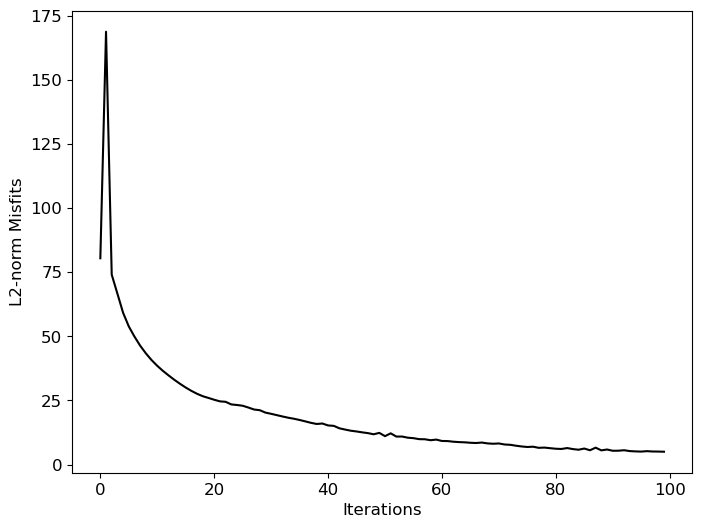

In [13]:
# plot the misfit
plt.figure(figsize=(8,6))
plt.plot(iter_loss,c='k')
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("L2-norm Misfits", fontsize=12)
plt.tick_params(labelsize=12)
plt.savefig(os.path.join(project_path,"inversion/misfit.png"),bbox_inches='tight',dpi=100)
plt.show()

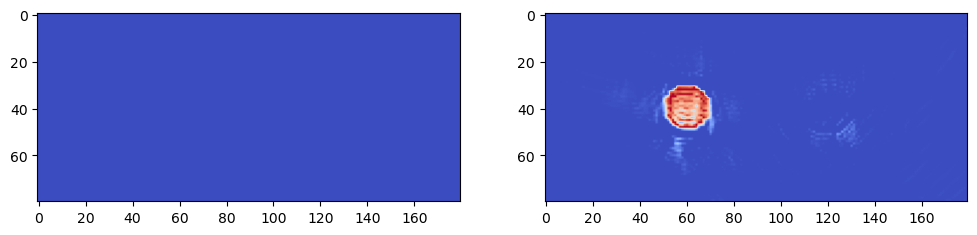

In [14]:
# plot the initial model and inverted resutls
plt.figure(figsize=(12,8))
plt.subplot(121)
plt.imshow(vp_init,cmap='coolwarm')
plt.subplot(122)
plt.imshow(iter_vp[-1],cmap='coolwarm')
plt.savefig(os.path.join(project_path,"inversion/inverted_vp.png"),bbox_inches='tight',dpi=100)
plt.show()

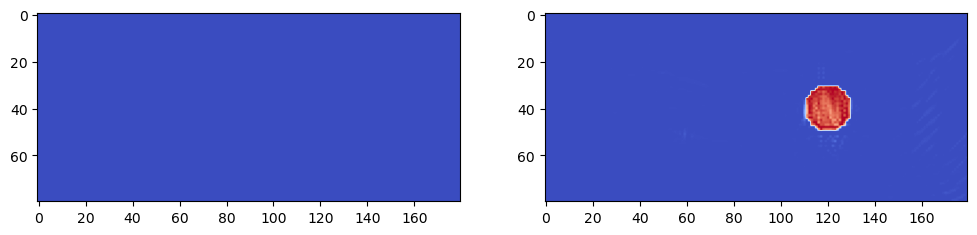

In [15]:
# plot the initial model and inverted resutls
plt.figure(figsize=(12,8))
plt.subplot(121)
plt.imshow(vs_init,cmap='coolwarm')
plt.subplot(122)
plt.imshow(iter_vs[-1],cmap='coolwarm')
plt.savefig(os.path.join(project_path,"inversion/inverted_vs.png"),bbox_inches='tight',dpi=100)
plt.show()

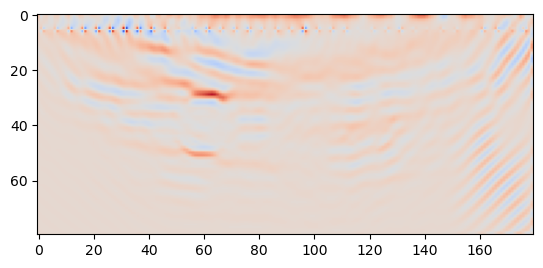

In [16]:
# plot the gradient
plt.figure()
plt.imshow(fwi.iter_vp_grad[-1],cmap='coolwarm')
plt.show()